# Abnormal Trading Volume and 1–5 Day Return Reversal after Large Daily Price Moves in U.S. Common Stocks

**Research notebook**  
This notebook presents the research process in the order it actually developed: initial hypothesis → formal test → diagnostic failure → magnitude control → revised hypothesis → robustness → locked holdout.

It is designed to be **reviewer-readable**, not merely a dump of scripts. The heavy raw-data download and full historical sample-construction code remain in the repository's `.py` files. This notebook reproduces the main aggregate evidence from the derived result files and documents the methodological decisions that produced the final specification.

**Important data/security note:** raw Massive licensed data and API credentials are not embedded in this notebook or repository. The full acquisition scripts request the API key interactively with `getpass()` and were run only under the assessment's authorised network conditions.

## Notebook map

1. Research question and hypothesis evolution  
2. Literature motivation  
3. Data, universe and security  
4. Variable definitions and parameter rationale  
5. Initial formal result and failed interpretation  
6. Move-magnitude confound diagnostic  
7. 1%-rank magnitude control  
8. Main development results  
9. Continuous residual-magnitude control  
10. Parameter robustness  
11. Locked holdout  
12. Interpretation, limitations and future work  
13. Experiment record, decision log and assistance disclosure

In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import display, Image, Markdown

ROOT = Path('.')
RESULTS = ROOT / 'results'
FINAL = RESULTS / 'final_outputs'
DOCS = ROOT / 'documentation'

required = [
    RESULTS / 'formal_development_daily_spreads.csv',
    RESULTS / 'move_magnitude_diagnostic.csv',
    RESULTS / 'magnitude_control_balance.csv',
    RESULTS / 'magnitude_controlled_development.csv',
    RESULTS / 'development_robustness_daily.csv',
    RESULTS / 'locked_holdout_daily.csv',
    FINAL / 'figure2_positive_negative_asymmetry.png',
    FINAL / 'figure3_negative_5d_robustness.png',
    FINAL / 'figure1_negative_development_vs_holdout.png',
]

missing = [str(p) for p in required if not p.exists()]
print('Notebook root:', ROOT.resolve())
print('Required derived files present:', len(missing) == 0)
if missing:
    print('Missing:', missing)

Notebook root: /Users/yoland/Documents/Quant Research
Required derived files present: True


# 1. Research Question and Hypothesis Evolution

### Final research question

> Among point-in-time U.S. common stocks priced at least $5 with trailing 20-day average dollar volume of at least $1 million, does abnormal trading volume on a large-move day—measured as current trading volume relative to the stock's previous 20-trading-day average—contain incremental information about cumulative returns over the following 1, 3 and 5 trading days, after conditioning on the direction and magnitude of the signal-day close-to-close return?

### Initial hypothesis

The initial hypothesis predicted **same-direction continuation**: after a large daily move, unusually high abnormal volume would be associated with stronger continuation over the next 1D, 3D and 5D.

### Revised hypothesis

Development evidence contradicted the negative-side continuation prediction. After diagnosing and controlling for signal-day move magnitude, the revised hypothesis became:

> Following large negative daily price moves, unusually high abnormal trading volume is associated with stronger return reversal over the following 3–5 trading days, while the corresponding relationship following large positive moves is substantially weaker.

The revised hypothesis and performance-related main methodology were frozen **before holdout return performance was examined**.

# 2. Literature Motivation

Three papers motivated different components of the question rather than serving as exact replications:

- **Jegadeesh & Titman (1993)** motivates the broader idea that past returns may contain information about subsequent returns, although their classic momentum setting is much longer-horizon than this project.
- **Lee & Swaminathan (2000)** motivates treating trading activity as an additional state variable beyond price history alone.
- **Gökçen & Post (2018)** is closer to the short-horizon setting because it studies trading volume, return variability and short-term momentum.

This project differs by conditioning specifically on large daily price moves, using stock-specific abnormal volume, separating positive and negative movers, testing 1D/3D/5D outcomes, and explicitly controlling the magnitude of the signal-day move before comparing High- and Low-AVOL stocks.

# 3. Data, Universe Construction and Security

The study uses Massive U.S. equity data from 2015–2025:

- **Daily Market Summary / Aggregate Bars** for adjusted daily OHLCV;
- **Historical Ticker Reference** for point-in-time U.S. common-stock (`type=CS`) universes.

The historical common-stock universe is refreshed on the **first valid trading day of each month**. Daily observations are intersected with that month's historical universe before the price and liquidity filters are applied.

### Primary universe filters

- Signal-day price ≥ **$5**
- Trailing **ADV20 ≥ $1M**, where ADV20 is the average of `Close × Volume` over the previous 20 consecutive valid market trading days
- Sufficient consecutive history to calculate the previous close, AVOL20 and ADV20

The price filter reduces very-low-priced-stock and microstructure concerns. The liquidity threshold was chosen before formal factor-performance evaluation using the monthly-snapshot liquidity distribution, and $5M/$10M thresholds are reserved for robustness checks.

### Credential handling

The acquisition scripts use interactive `getpass()` input. No API key is written to notebook cells, source code, `.env` files, outputs, or Git history. Raw licensed Massive data are intentionally excluded from the submitted repository.

In [37]:
# The following is a NON-NETWORK security illustration only.
# The real acquisition scripts are download_full_daily.py and download_monthly_universes.py.
# No API call is made by this cell.

safe_acquisition_pattern = '''
from getpass import getpass
API_KEY = getpass("Enter Massive API key: ")
headers = {"Authorization": f"Bearer {API_KEY}"}
# Network location was checked before Massive access in the acquisition scripts.
'''
print(safe_acquisition_pattern)


from getpass import getpass
API_KEY = getpass("Enter Massive API key: ")
headers = {"Authorization": f"Bearer {API_KEY}"}
# Network location was checked before Massive access in the acquisition scripts.



## 3.1 Liquidity-threshold diagnostic

The $1M ADV20 threshold was not selected by trying multiple cutoffs and choosing the best backtest. Before formal factor-performance evaluation, I inspected the ADV20 distribution at monthly point-in-time universe snapshot dates among common stocks already satisfying the $5 price filter.

In [22]:
liq_text = (RESULTS / 'liquidity_distribution.txt').read_text()
start = liq_text.index('COMMON STOCKS WITH PRICE >= $5')
print(liq_text[start:])

COMMON STOCKS WITH PRICE >= $5
Observations: 513251
P1: $25,238
P5: $89,774
P10: $214,929
P20: $680,013
P25: $1,107,866
P50: $8,199,271
P75: $42,045,499
P80: $60,987,839
P90: $149,571,635
P95: $285,552,692
P99: $935,310,079

Share above candidate thresholds:
>= $100,000: 94.5%
>= $500,000: 83.0%
>= $1,000,000: 76.0%
>= $2,000,000: 68.5%
>= $5,000,000: 56.9%
>= $10,000,000: 47.1%
>= $25,000,000: 32.9%
>= $50,000,000: 22.6%


**Decision.** The 25th percentile was about $1.11M and about 76% of price-filtered observations exceeded $1M. I therefore used **ADV20 ≥ $1M** as the main broad-but-investable liquidity screen, while $5M and $10M were treated only as robustness checks.

# 4. Variable Definitions and Parameter Rationale

### Signal-day return

\[
r_{i,t} = \frac{Close_{i,t}}{Close_{i,t-1}} - 1
\]

This is **close-to-close**, so it captures both overnight and intraday adjustment. A future extension can decompose overnight and open-to-close components.

### Abnormal volume

\[
AVOL20_{i,t}=\frac{Volume_{i,t}}{\frac{1}{20}\sum_{j=1}^{20} Volume_{i,t-j}}
\]

The signal day is excluded from the trailing average. A value of 2 means current volume is twice the prior-20-day average.

### Future outcomes

\[
R^{(h)}_{i,t}=\frac{Close_{i,t+h}}{Close_{i,t}}-1,\quad h\in\{1,3,5\}
\]

### Main parameters and rationale

| Component | Main choice | Rationale |
|---|---|---|
| Mover tail | Top / bottom 20% | Large relative moves while retaining enough stocks for narrow within-tail matching |
| AVOL lookback | 20D | Roughly one trading month; balances recency and stability |
| Future horizons | 1D / 3D / 5D | Immediate, multi-day and approximately one-week adjustment |
| Price screen | $5 | Reduces influence of very low-priced stocks |
| Liquidity | ADV20 ≥ $1M | Removes least-liquid portion without collapsing breadth |
| Magnitude control | 1%-rank bins | Chosen after 5%-bins still left material signal-day imbalance |
| AVOL split | Within-bin median | Balanced relative High/Low groups without an arbitrary absolute AVOL cutoff |
| Inference | HAC lag = h−1 | Accounts for serial correlation from overlapping h-day outcomes |

In [23]:
# Main locked parameters, matching the source implementation.
PRICE_MIN = 5.0
ADV20_MIN = 1_000_000
AVOL_LOOKBACK = 20
MOVER_TAIL = 0.20
HORIZONS = [1, 3, 5]
HAC_LAGS = {h: h - 1 for h in HORIZONS}

pd.Series({
    'Price minimum': PRICE_MIN,
    'ADV20 minimum': ADV20_MIN,
    'AVOL lookback': AVOL_LOOKBACK,
    'Mover tail': MOVER_TAIL,
    'Horizons': HORIZONS,
    'HAC lags': HAC_LAGS,
})

Price minimum                   5.0
ADV20 minimum               1000000
AVOL lookback                    20
Mover tail                      0.2
Horizons                  [1, 3, 5]
HAC lags         {1: 0, 3: 2, 5: 4}
dtype: object

## 4.1 Core magnitude-control implementation

On each day, eligible stocks are ranked cross-sectionally by signal-day return. The top 20% and bottom 20% tails are each divided into **twenty 1-percentile return-rank bins**. Within each bin, AVOL is split at the bin median.

The primary implementation requires all 20 bins to contain valid High- and Low-AVOL groups. At a given future horizon, the signal date is retained only if all 20 bins continue to have valid future-return observations on both sides. The daily spread is the equal-weight mean of the 20 bin-level High-minus-Low spreads.

In [24]:
# Compact representation of the exact core sorting logic used by the project.

def build_groups_for_review(day_df, mover):
    if mover == 'positive':
        group = day_df[day_df['return_rank'] >= 0.80].copy()
        edges = np.round(np.arange(0.80, 1.001, 0.01), 2)
    else:
        group = day_df[day_df['return_rank'] <= 0.20].copy()
        edges = np.round(np.arange(0.00, 0.201, 0.01), 2)

    labels = [f'{edges[i]:.2f}-{edges[i+1]:.2f}' for i in range(len(edges)-1)]
    group['magnitude_bin'] = pd.cut(
        group['return_rank'], bins=edges, labels=labels,
        include_lowest=True, right=True
    )

    out = {}
    for label in labels:
        b = group[group['magnitude_bin'] == label]
        if b.empty:
            continue
        med = b['avol'].median()
        low = b[b['avol'] < med]
        high = b[b['avol'] >= med]
        if low.empty or high.empty:
            continue
        out[label] = {'low': low, 'high': high}

    return out if len(out) == 20 else None

print('Expected number of 1%-rank bins per mover tail: 20')

Expected number of 1%-rank bins per mover tail: 20


# 5. Initial Formal Result: A Result That Could Not Yet Be Interpreted

The first formal specification used the point-in-time universe, price/liquidity filters, top/bottom-20% mover tails and one broad High/Low AVOL split per tail. It produced positive High-minus-Low spreads for **negative movers**, opposite to the original continuation prediction.

Rather than treating this immediately as a reversal finding, I investigated whether High-AVOL stocks also had more extreme signal-day moves.

In [25]:
def hac_mean(series, horizon):
    x = pd.Series(series).dropna().astype(float)
    X = np.ones((len(x), 1))
    fit = sm.OLS(x.values, X).fit(
        cov_type='HAC', cov_kwds={'maxlags': horizon - 1}
    )
    return pd.Series({
        'N': len(x),
        'Spread (bps)': fit.params[0] * 10000,
        'HAC SE (bps)': fit.bse[0] * 10000,
        'HAC t-stat': fit.tvalues[0],
    })

coarse = pd.read_csv(RESULTS / 'formal_development_daily_spreads.csv')
rows = []
for mover in ['positive', 'negative']:
    for h in HORIZONS:
        x = coarse[(coarse.mover == mover) & (coarse.horizon == h)]
        s = hac_mean(x['spread'], h)
        s['Mover'] = mover.capitalize()
        s['Horizon'] = f'{h}D'
        rows.append(s)
coarse_summary = pd.DataFrame(rows)[['Mover','Horizon','N','Spread (bps)','HAC t-stat']]
display(coarse_summary.round(2))

,Mover,Horizon,N,Spread (bps),HAC t-stat
0,Positive,1D,2511.0,0.27,0.27
1,Positive,3D,2511.0,-0.89,-0.43
2,Positive,5D,2511.0,-0.57,-0.19
3,Negative,1D,2511.0,3.62,3.21
4,Negative,3D,2511.0,9.98,4.37
5,Negative,5D,2511.0,16.32,4.60


**Interpretation.** A positive spread for negative movers means High-AVOL losers subsequently outperform Low-AVOL losers—i.e., **reversal**, not continuation. But at this stage the AVOL groups were not adequately matched on the initial move magnitude, so the result was not yet interpreted as incremental AVOL information.

# 6. Diagnostic: Signal-Day Move-Magnitude Confound

The key diagnostic asks whether High-AVOL and Low-AVOL stocks inside the broad mover tails experienced comparable initial price moves.

In [26]:
diag = pd.read_csv(RESULTS / 'move_magnitude_diagnostic.csv')
diag_summary = diag.groupby('mover').agg(
    Low_signal_return=('low_signal_return','mean'),
    High_signal_return=('high_signal_return','mean'),
    High_minus_Low=('high_minus_low_signal_return','mean'),
    Low_mean_rank=('low_mean_rank','mean'),
    High_mean_rank=('high_mean_rank','mean'),
)
for c in ['Low_signal_return','High_signal_return','High_minus_Low']:
    diag_summary[c] *= 100

display(diag_summary.rename(columns={
    'Low_signal_return':'Low signal return (%)',
    'High_signal_return':'High signal return (%)',
    'High_minus_Low':'High-Low signal gap (pp)',
}).round(3))

,Low signal return (%),High signal return (%),High-Low signal gap (pp),Low_mean_rank,High_mean_rank
mover,,,,,
negative,-2.839,-3.648,-0.809,0.109,0.091
positive,2.780,4.136,1.357,0.888,0.912


**Diagnostic conclusion.** High-AVOL positive movers rose more on the signal day, and High-AVOL negative movers fell more. For negative movers, the broad-sort averages were roughly **−3.65% vs −2.84%**. Therefore a stronger subsequent rebound could simply reflect a larger initial decline.

### Failed 5%-bin control

I first divided each 20% tail into four 5-percentage-point return-rank bins and re-split AVOL within each bin. This improved balance, but the remaining High-minus-Low signal-day gaps were still approximately **+68.2 bps** for positive movers and **−38.7 bps** for negative movers.

**Decision:** refine to 1%-rank bins based on **balance**, before using the controlled future-return performance to choose the specification.

# 7. Primary 1%-Rank Magnitude Control

The final main design divides each 20% mover tail into twenty 1-percentile rank bins, then performs the AVOL median split inside each bin. This was intended to compare stocks with very similar initial return ranks rather than simply comparing all High-AVOL and Low-AVOL movers together.

In [27]:
bal = pd.read_csv(RESULTS / 'magnitude_control_balance.csv')
balance_summary = bal.groupby('mover').agg(
    Signal_days=('date','nunique'),
    Low_signal_return=('low_signal_return','mean'),
    High_signal_return=('high_signal_return','mean'),
    Signal_gap=('signal_return_difference','mean'),
    Low_rank=('low_rank','mean'),
    High_rank=('high_rank','mean'),
)
for c in ['Low_signal_return','High_signal_return','Signal_gap']:
    balance_summary[c] *= 10000

display(balance_summary.rename(columns={
    'Low_signal_return':'Low signal return (bps)',
    'High_signal_return':'High signal return (bps)',
    'Signal_gap':'High-Low signal gap (bps)',
}).round(2))

,Signal_days,Low signal return (bps),High signal return (bps),High-Low signal gap (bps),Low_rank,High_rank
mover,,,,,,
negative,2506,-317.39,-333.16,-15.77,0.1,0.1
positive,2506,330.89,359.00,28.11,0.9,0.9


**Balance result.** Mean cross-sectional return ranks became almost identical between High- and Low-AVOL groups. The remaining signal-day return gap fell to about **+28.1 bps** for positive movers and **−15.8 bps** for negative movers. I stopped refining the bin width here rather than continuing until a preferred future-return result appeared.

# 8. Main Development Results

The primary development sample uses actual signal dates from **2015-02-02 through 2025-01-24**. Late-January signals are excluded so that the longest 5D development outcomes finish before the February 2025 holdout begins.

In [28]:
dev = pd.read_csv(RESULTS / 'magnitude_controlled_development.csv', parse_dates=['signal_date'])

main_rows = []
for mover in ['positive','negative']:
    for h in HORIZONS:
        x = dev[(dev.mover == mover) & (dev.horizon == h)].copy()
        hs = hac_mean(x['spread'], h)
        hs['Mover'] = mover.capitalize()
        hs['Horizon'] = f'{h}D'
        hs['Low AVOL future (bps)'] = x['low_avol_return'].mean() * 10000
        hs['High AVOL future (bps)'] = x['high_avol_return'].mean() * 10000
        hs['Signal gap (bps)'] = (x['high_signal_return'] - x['low_signal_return']).mean() * 10000
        main_rows.append(hs)

main_dev = pd.DataFrame(main_rows)[[
    'Mover','Horizon','N','Low AVOL future (bps)','High AVOL future (bps)',
    'Spread (bps)','HAC t-stat','Signal gap (bps)'
]]
display(main_dev.round(2))

,Mover,Horizon,N,Low AVOL future (bps),High AVOL future (bps),Spread (bps),HAC t-stat,Signal gap (bps)
0,Positive,1D,2506.0,-0.07,1.32,1.39,1.40,28.11
1,Positive,3D,2506.0,-2.82,-0.11,2.71,1.23,28.11
2,Positive,5D,2506.0,-4.32,0.09,4.42,1.35,28.11
3,Negative,1D,2506.0,-2.50,2.01,4.52,4.10,-15.77
4,Negative,3D,2506.0,-2.38,10.50,12.89,5.29,-15.77
5,Negative,5D,2506.0,-3.04,18.00,21.04,5.50,-15.77


### Main interpretation

- **Positive movers:** spreads are small and HAC t-statistics are weak.
- **Negative movers:** High-minus-Low spreads are approximately **+4.52, +12.89 and +21.04 bps** at 1D/3D/5D, with HAC t-statistics approximately **4.10, 5.29 and 5.50**.
- Because these stocks had just experienced large **negative** returns, a positive future High-minus-Low spread means the High-AVOL group subsequently rebounds more strongly: **reversal rather than continuation**.
- The increasing spread from 1D to 5D suggests that the relationship is not only an immediate next-day bounce.

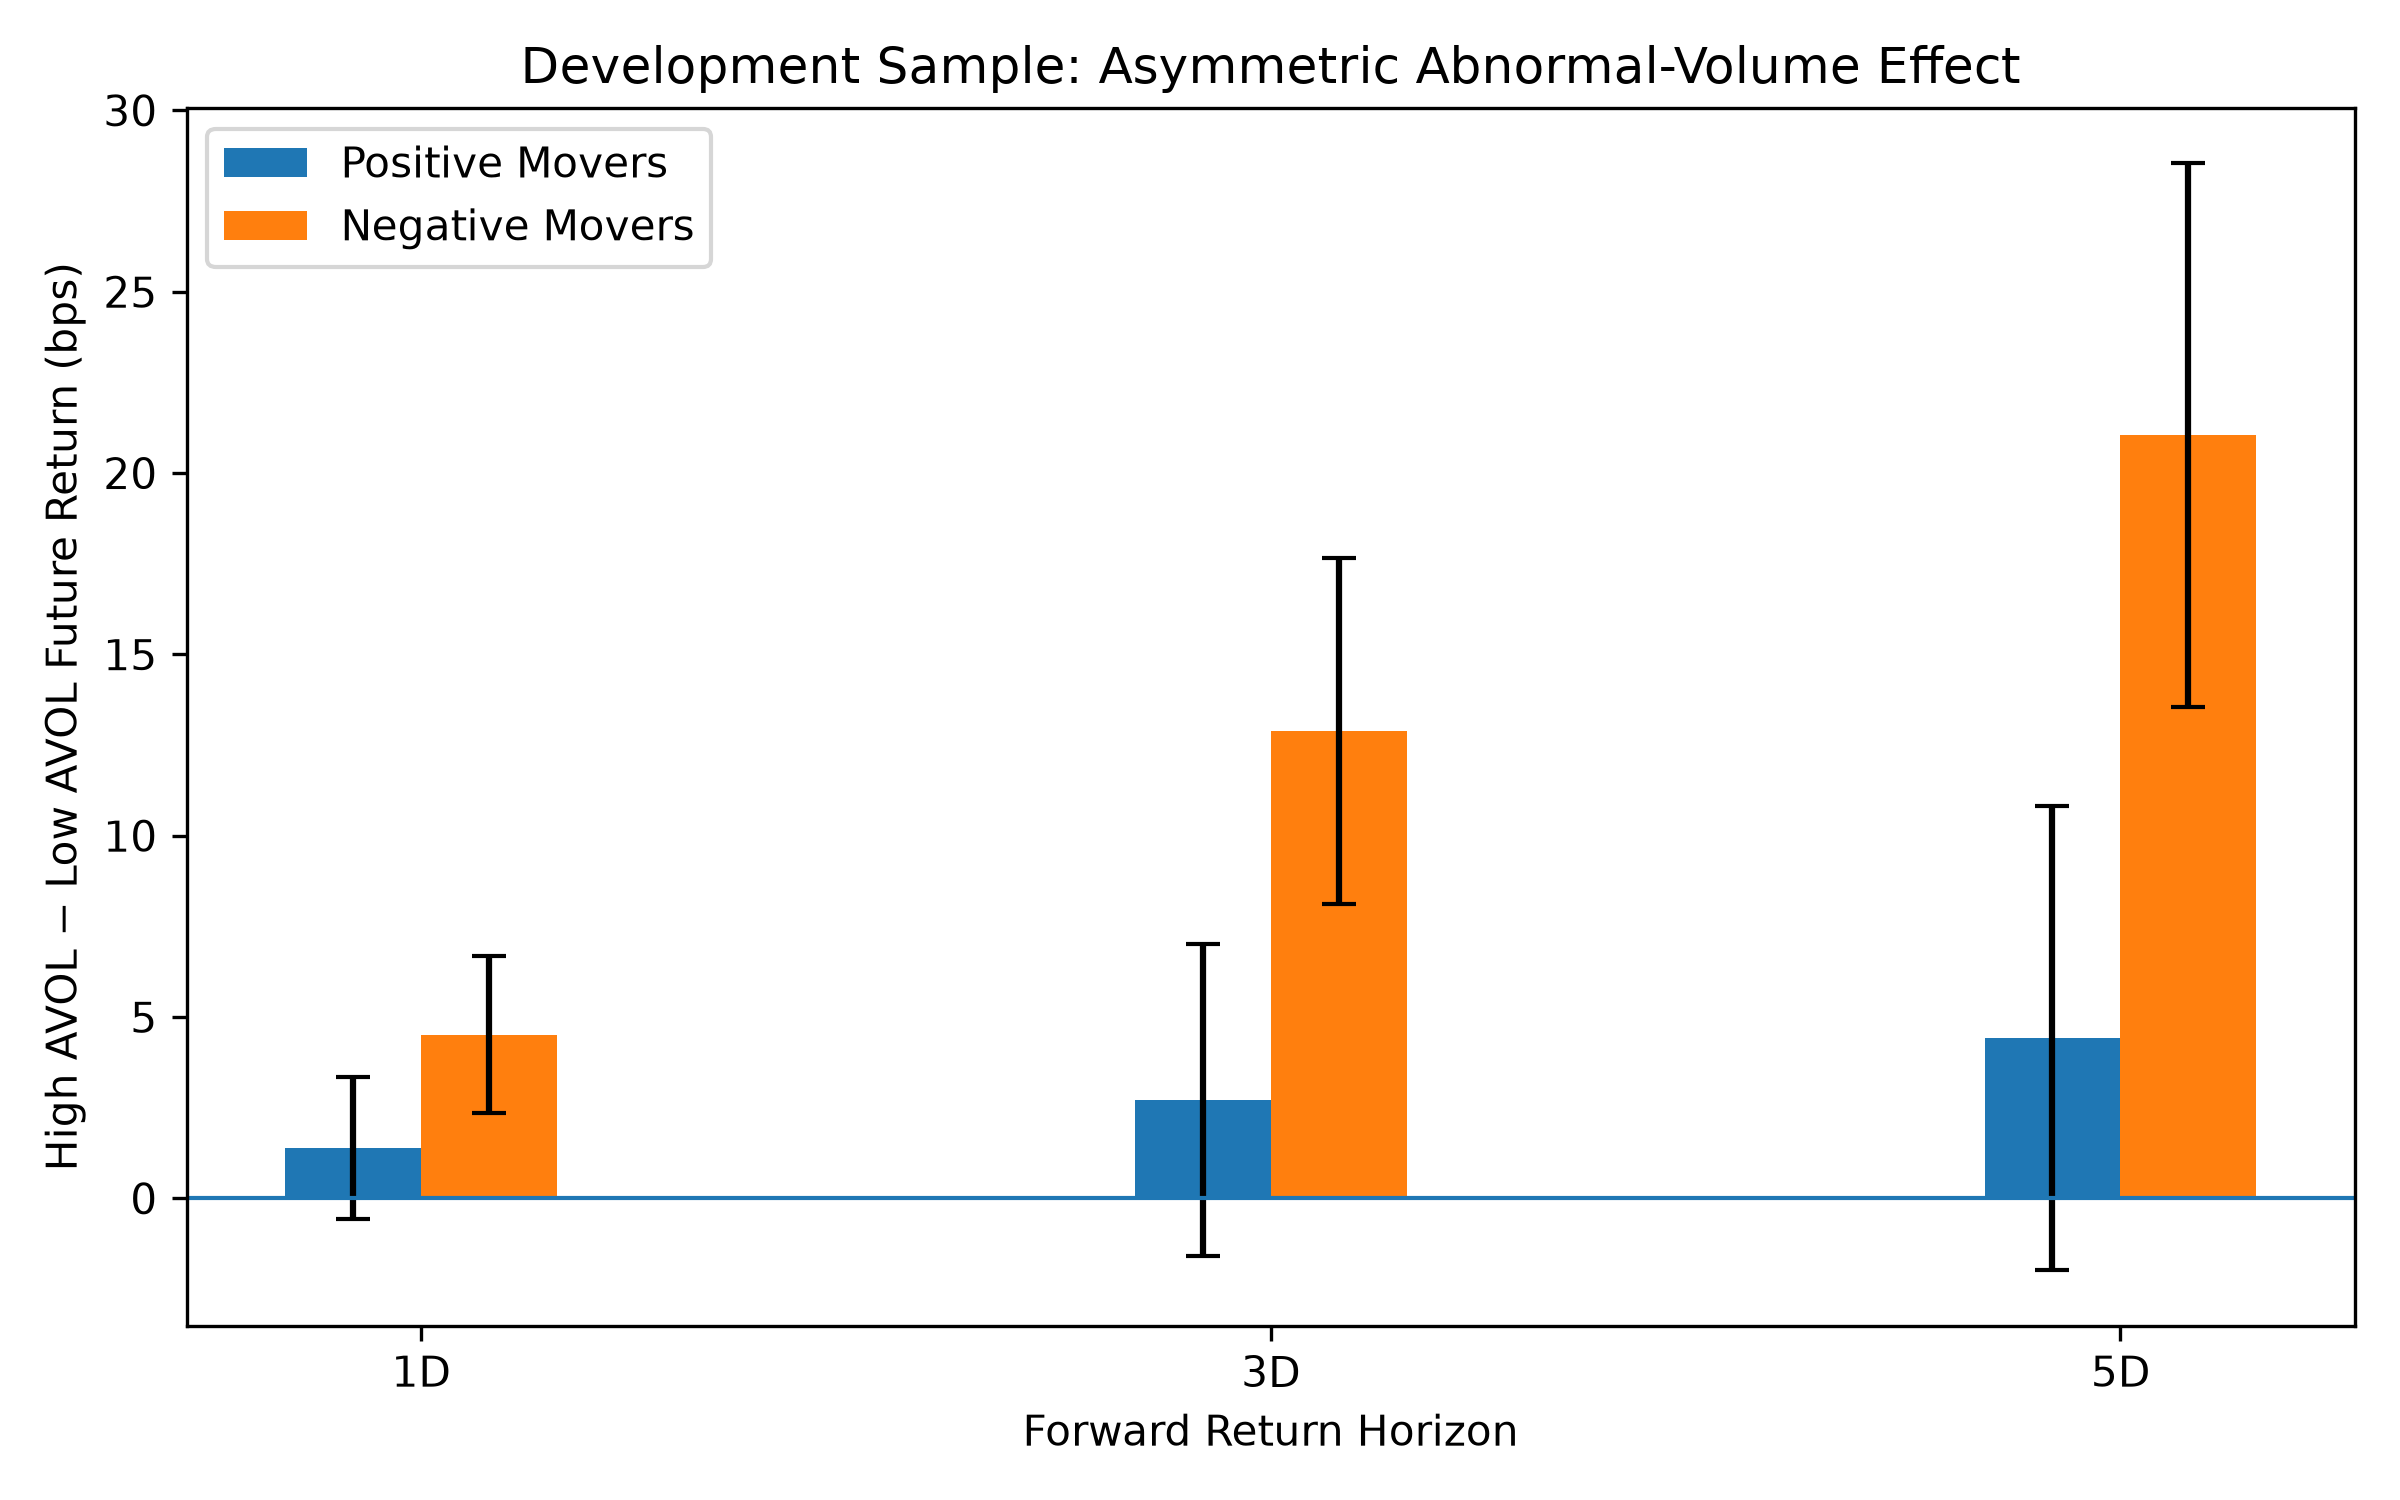

In [29]:
display(Image(filename=str(FINAL / 'figure2_positive_negative_asymmetry.png')))

**Figure 1 interpretation.** The positive-mover confidence intervals overlap zero, while the negative-mover High-minus-Low spreads are larger and increase from 1D to 5D. This asymmetry is the empirical reason the hypothesis was revised toward negative-mover reversal rather than symmetric continuation.

# 9. Continuous Control for the Residual Signal-Day Gap

The 1%-bin design greatly improves rank balance but does not make the average signal-day returns exactly equal. I therefore estimate, for each mover and horizon:

\[
Spread_{t,h}=\alpha_h+\beta_h\,SignalGap_t+\epsilon_{t,h}
\]

where `SignalGap = High-AVOL signal-day return − Low-AVOL signal-day return`. The intercept \(\alpha_h\) estimates the High-minus-Low future spread at a zero signal-day gap, conditional on this linear control. HAC standard errors again use lag `h−1`.

In [30]:
def continuous_control(df, horizon):
    y = df['spread'].astype(float)
    gap = (df['high_signal_return'] - df['low_signal_return']).astype(float)
    X = sm.add_constant(gap)
    fit = sm.OLS(y, X).fit(
        cov_type='HAC', cov_kwds={'maxlags': horizon - 1}
    )
    return pd.Series({
        'N': len(df),
        'Raw spread (bps)': y.mean() * 10000,
        'Mean signal gap (bps)': gap.mean() * 10000,
        'Adjusted spread (bps)': fit.params['const'] * 10000,
        'Adjusted HAC t-stat': fit.tvalues['const'],
        'R-squared': fit.rsquared,
    })

control_rows = []
for mover in ['positive','negative']:
    for h in HORIZONS:
        x = dev[(dev.mover == mover) & (dev.horizon == h)].copy()
        s = continuous_control(x, h)
        s['Mover'] = mover.capitalize(); s['Horizon'] = f'{h}D'
        control_rows.append(s)
control = pd.DataFrame(control_rows)[[
    'Mover','Horizon','N','Raw spread (bps)','Mean signal gap (bps)',
    'Adjusted spread (bps)','Adjusted HAC t-stat','R-squared'
]]
display(control.round(3))

,Mover,Horizon,N,Raw spread (bps),Mean signal gap (bps),Adjusted spread (bps),Adjusted HAC t-stat,R-squared
0,Positive,1D,2506.0,1.389,28.115,2.101,2.013,0.002
1,Positive,3D,2506.0,2.709,28.115,4.068,1.818,0.002
2,Positive,5D,2506.0,4.418,28.115,5.659,1.686,0.001
3,Negative,1D,2506.0,4.517,-15.775,2.913,1.678,0.001
4,Negative,3D,2506.0,12.886,-15.775,8.324,2.483,0.002
5,Negative,5D,2506.0,21.039,-15.775,16.846,3.454,0.001


**Interpretation.** The adjustment reduces the negative-mover effect, especially at 1D, showing that residual initial-move differences explain part of the raw spread. However, the negative 3D and 5D adjusted spreads remain positive at approximately **+8.32 bps** and **+16.85 bps**. This is why the revised pre-holdout hypothesis emphasized the **3–5 day** reversal.

# 10. Parameter Robustness

The purpose of robustness analysis is not to search for the best-looking parameter combination. The main specification is retained while one dimension is varied at a time:

- AVOL lookback: 10D / 20D / 40D
- ADV20 threshold: $1M / $5M / $10M
- mover tail: 20% / 10%

The robustness runner additionally requires at least four stocks per 1%-rank bin before the within-bin AVOL split. This produces a slightly different baseline sample (**2,503 dates**) from the primary development sample (**2,506 dates**), explaining the very small difference between the main primary and robustness-baseline numbers.

In [31]:
rob = pd.read_csv(FINAL / 'table2_negative_robustness.csv')
display(rob.round(2))

,Specification,Horizon,N,Spread (bps),Median (bps),HAC t-stat,Signal-Day Gap (bps)
0,"Main: AVOL20, ADV $1M, Tail 20%",3,2503,12.91,11.37,5.30,-15.77
1,"Main: AVOL20, ADV $1M, Tail 20%",5,2503,21.15,19.41,5.53,-15.77
2,AVOL lookback 10D,3,2503,13.70,11.87,6.04,-14.05
3,AVOL lookback 10D,5,2503,20.70,22.73,5.86,-14.05
4,AVOL lookback 40D,3,2485,10.63,7.75,4.37,-18.01
5,AVOL lookback 40D,5,2485,17.97,16.87,4.68,-18.01
6,ADV >= $5M,3,2509,10.56,9.70,4.45,-13.29
7,ADV >= $5M,5,2509,15.95,15.00,4.29,-13.29
8,ADV >= $10M,3,2510,9.06,9.09,3.88,-12.06
9,ADV >= $10M,5,2510,13.76,13.71,3.75,-12.06


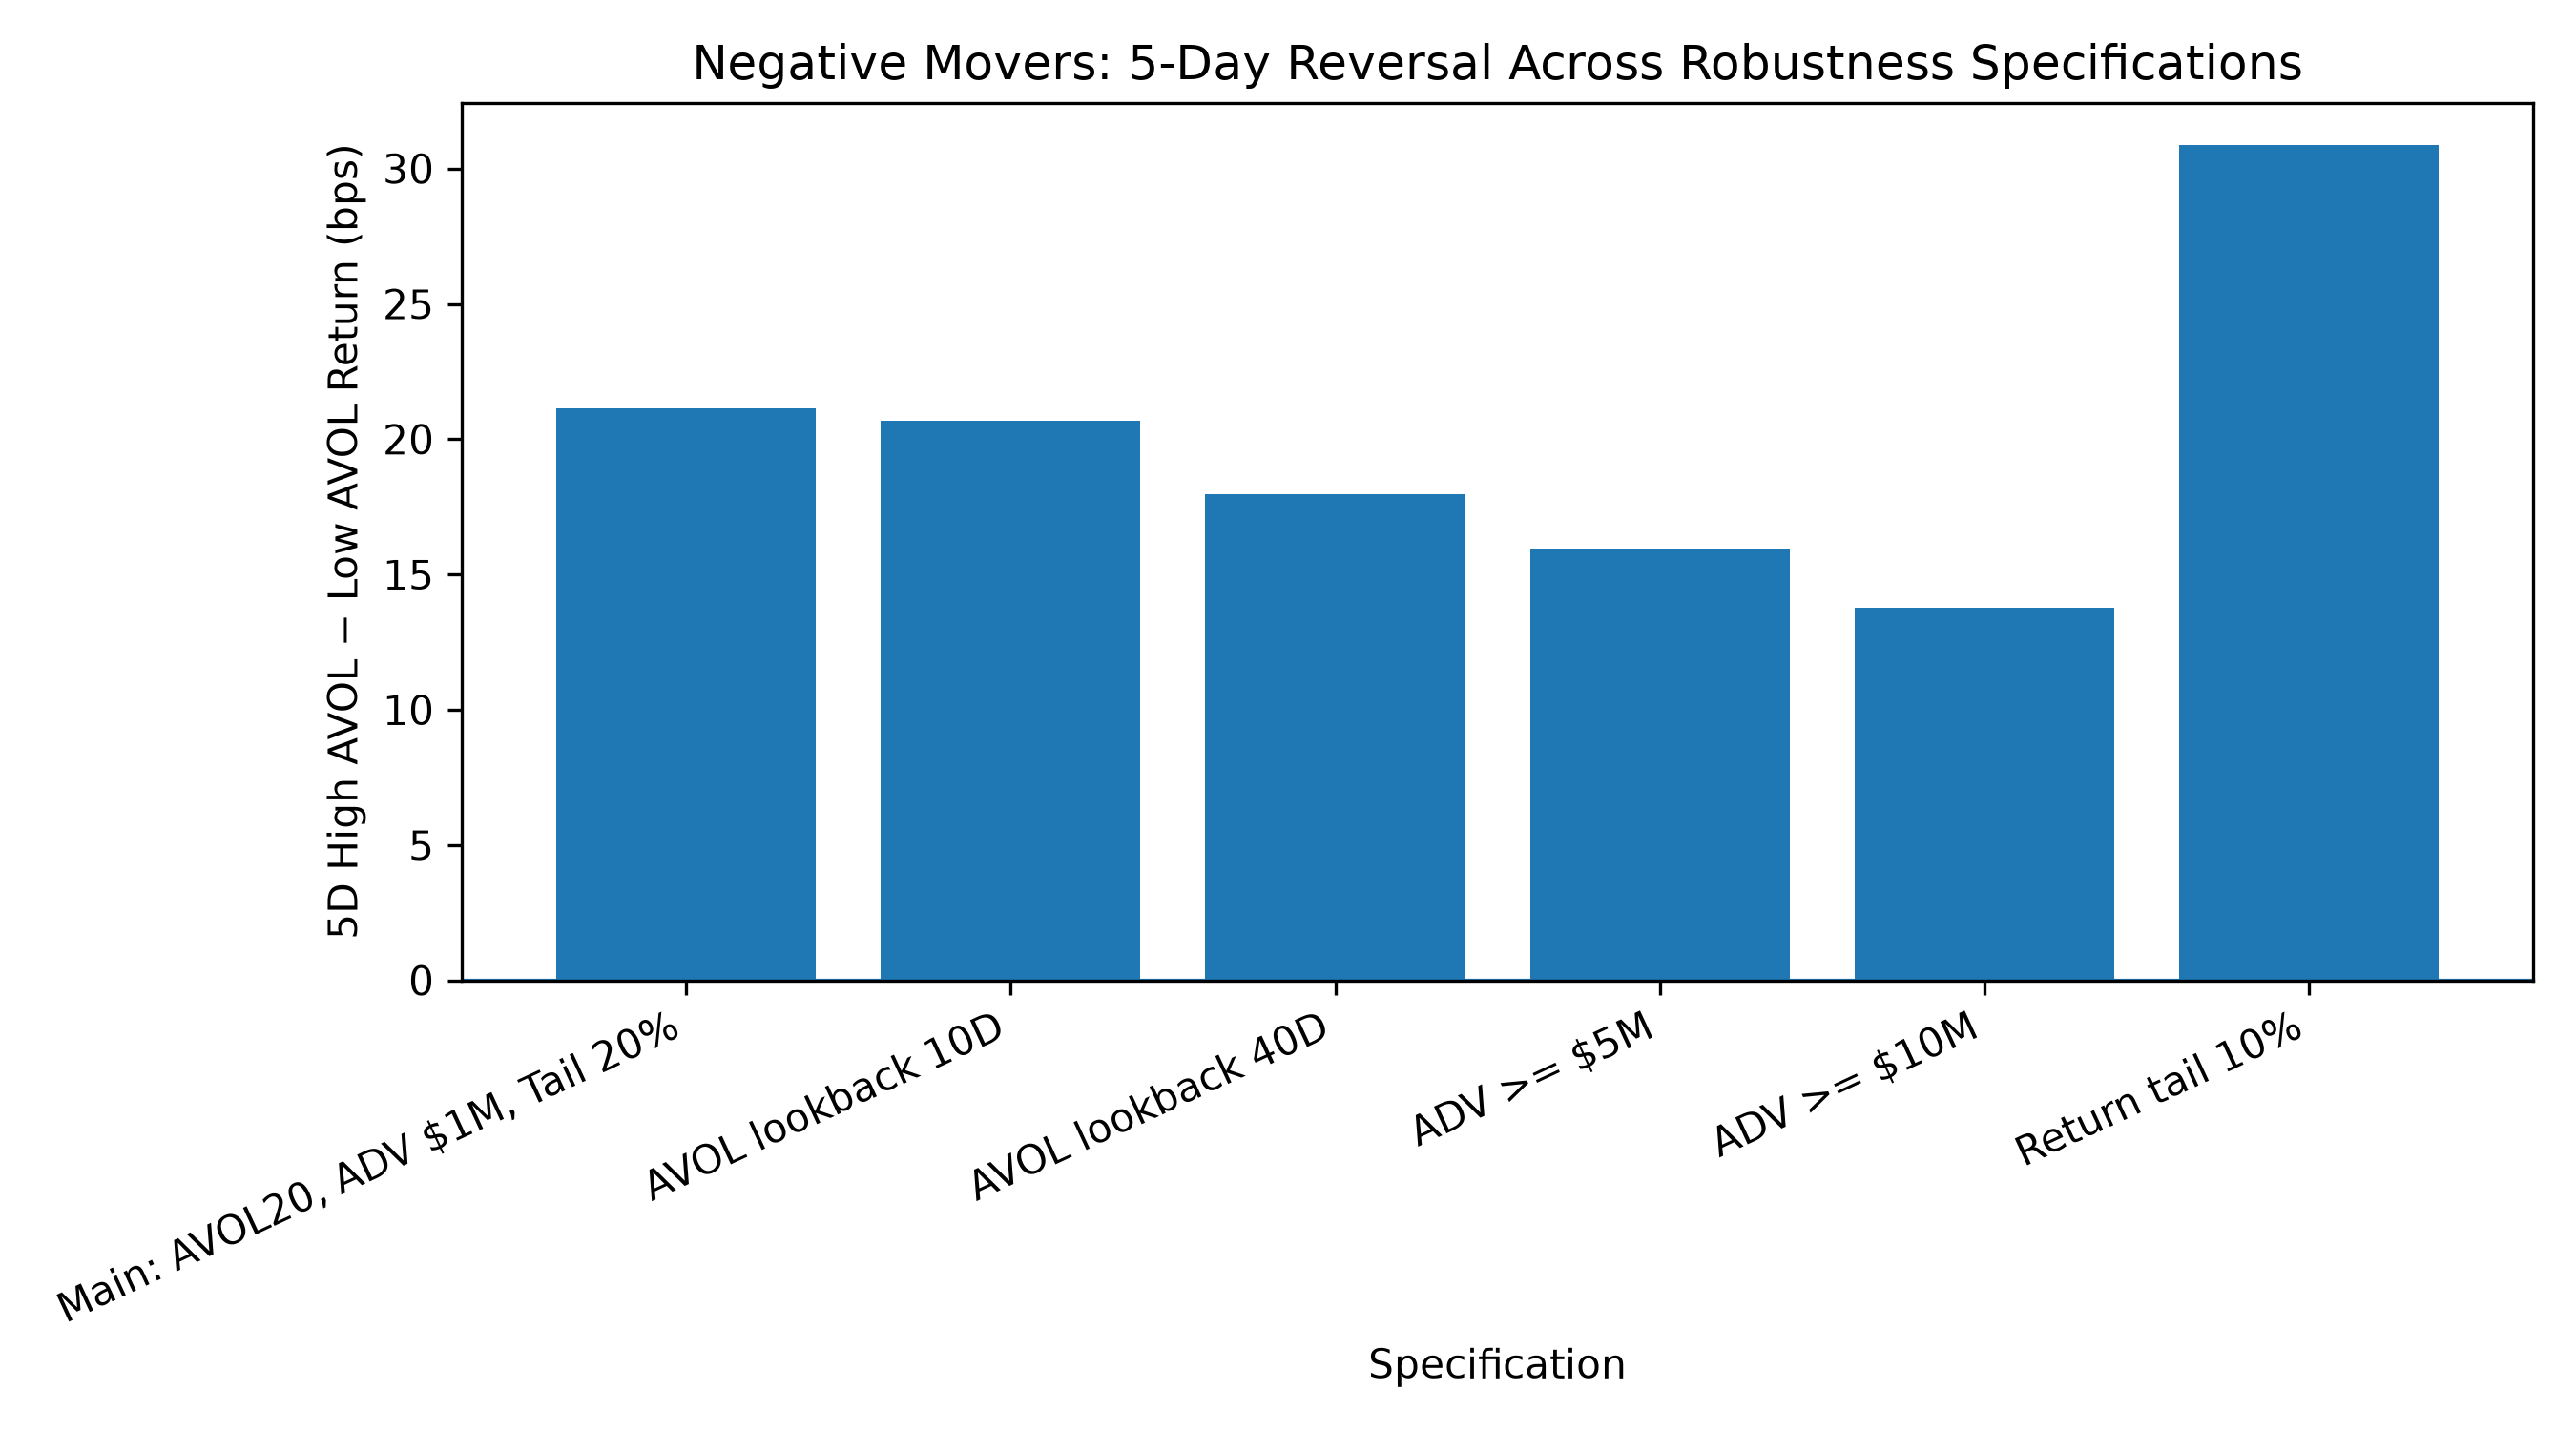

In [32]:
display(Image(filename=str(FINAL / 'figure3_negative_5d_robustness.png')))

**Figure 2 interpretation.** The negative-mover 5D spread remains positive across shorter/longer AVOL baselines, stricter liquidity thresholds and a more extreme 10% mover tail. The 10% tail produces the largest estimate, but it is deliberately **not** adopted as the main model because selecting the best-performing robustness variant after seeing results would introduce specification-selection bias.

# 11. Locked Holdout Evaluation

The revised hypothesis and main performance-related parameters were frozen before holdout return performance was examined. The actual holdout contains **225 valid signal dates from 2025-02-03 through 2025-12-23**; the end date leaves enough subsequent trading days to calculate the 5D outcome before the end of the data.

A liquidity-distribution diagnostic did use observations extending through 2025 before formal return-performance evaluation, so the precise claim is **not** that every holdout datum was completely untouched. The claim is that **holdout return performance was not examined before the revised hypothesis and performance methodology were locked**.

In [33]:
hold = pd.read_csv(RESULTS / 'locked_holdout_daily.csv', parse_dates=['signal_date'])

hold_rows = []
for mover in ['positive','negative']:
    for h in HORIZONS:
        x = hold[(hold.mover == mover) & (hold.horizon == h)].copy()
        hs = hac_mean(x['spread'], h)
        adj = continuous_control(x, h)
        hold_rows.append({
            'Mover': mover.capitalize(),
            'Horizon': f'{h}D',
            'N': len(x),
            'Spread (bps)': hs['Spread (bps)'],
            'HAC t-stat': hs['HAC t-stat'],
            'Adjusted spread (bps)': adj['Adjusted spread (bps)'],
            'Adjusted HAC t-stat': adj['Adjusted HAC t-stat'],
        })
hold_summary = pd.DataFrame(hold_rows)
display(hold_summary.round(2))

,Mover,Horizon,N,Spread (bps),HAC t-stat,Adjusted spread (bps),Adjusted HAC t-stat
0,Positive,1D,225,-1.31,-0.27,-4.86,-0.80
1,Positive,3D,225,11.82,1.23,10.40,0.88
2,Positive,5D,225,14.84,1.01,13.32,0.80
3,Negative,1D,225,13.83,2.89,13.87,2.18
4,Negative,3D,225,42.74,3.69,49.00,3.09
5,Negative,5D,225,61.28,3.34,70.48,2.96


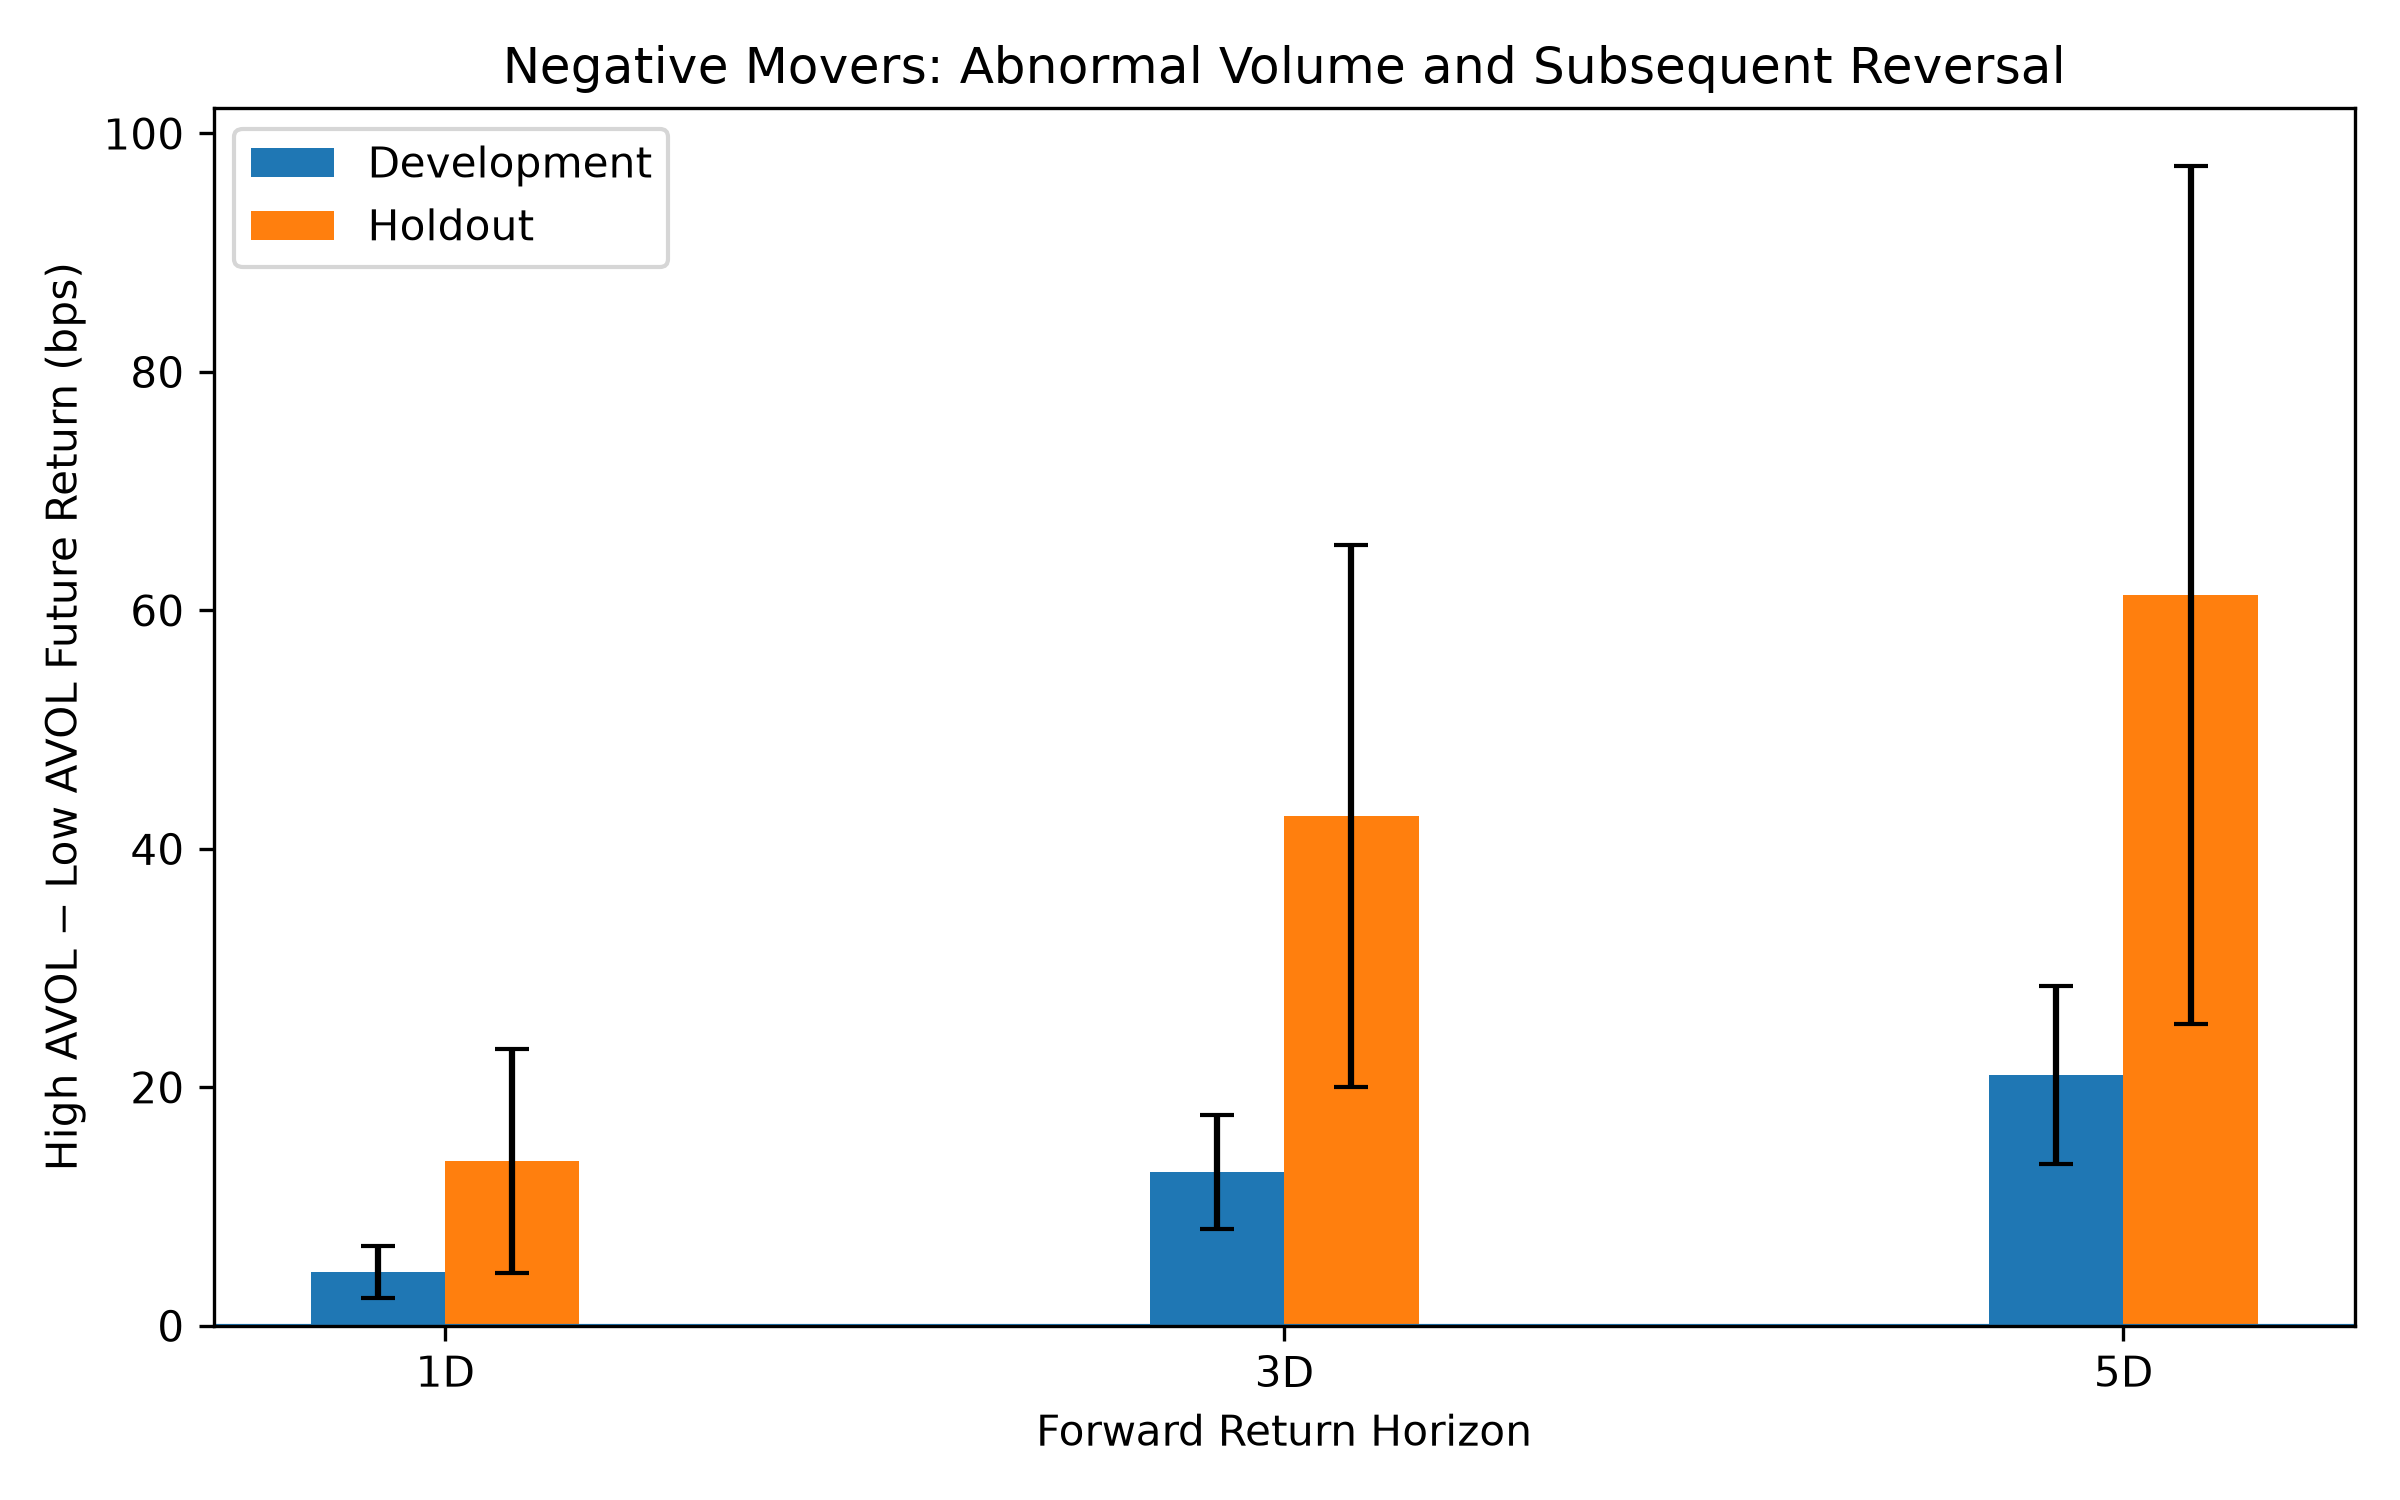

In [34]:
display(Image(filename=str(FINAL / 'figure1_negative_development_vs_holdout.png')))

**Figure 3 interpretation.** The negative-mover High-minus-Low spread remains positive at 1D, 3D and 5D in the holdout, so the **direction** of the revised relationship replicates outside the development sample. The holdout magnitude is much larger, however, so the holdout is better interpreted as evidence for directional replication than for a stable economic effect size. Regime dependence is a plausible explanation and is left for future research.

# 12. Combined Interpretation

The evidence supports three main conclusions:

1. The original **symmetric continuation** hypothesis is not supported.
2. The strongest relationship is among **negative movers**, where High-AVOL stocks subsequently outperform Low-AVOL stocks—consistent with **reversal**.
3. The negative-side relationship is strongest over **3D–5D**, remains positive after continuous residual-magnitude control, survives nearby parameter variations, and replicates in direction in the locked holdout.

The result is a **predictive association**, not a causal claim. The High-minus-Low spreads are also not equivalent to directly implementable PnL because the signal uses the completed signal-day close and volume, while execution costs and next-tradable-price effects are not modelled.

## 12.1 Limitations and future improvements

The main limitations are deliberately not “fixed” after observing the holdout, because repeatedly adding filters after seeing final performance would weaken the out-of-sample interpretation.

- **Causality / omitted events:** AVOL may coincide with earnings, news, analyst revisions, attention or liquidity shocks. Future work should separate event and non-event days.
- **Daily aggregation:** close-to-close returns combine overnight and intraday adjustment. Future work could decompose overnight returns, open-to-close returns and intraday volume timing.
- **Recent listings:** the consecutive 20-day history requirement excludes the newest IPO observations, but there is no additional seasoning-period rule. A minimum listing-age robustness test is a natural extension.
- **Monthly universe refresh:** substantially better than a current-universe backtest, but not a fully daily point-in-time universe.
- **Liquidity / microstructure:** Price ≥ $5 and ADV20 ≥ $1M do not fully control bid-ask spreads, trade count, depth, halts or price impact.
- **Other stock characteristics:** matching is tight on signal-day return rank, but not on size, volatility, beta, industry or longer-horizon returns.
- **Execution realism:** the signal requires full day-t close and volume; a real implementation would need an explicit post-signal execution time and price.
- **Costs:** commissions, spreads, slippage, impact, borrowing costs and short-sale constraints are not modelled.
- **Regime dependence:** holdout estimates are much larger than development estimates.
- **Multiple testing:** several horizons and robustness variants were inspected; future work could preregister the full empirical design or use formal multiple-testing adjustments.

# 13. Experiment Record

The project deliberately records failed and superseded experiments rather than presenting only the final specification. The complete table is maintained in `documentation/experiment_record.md`.

In [35]:
# Render the maintained experiment record inside the notebook.
display(Markdown((DOCS / 'experiment_record.md').read_text()))

# Experiment Record

This document records the meaningful experiments performed during the project, including unsuccessful, superseded and diagnostic experiments. Minor coding tests are omitted unless they materially affected the research design.

| ID | Hypothesis / Purpose | Universe & Period | Data / Features | Rule / Important Parameters | Main Result | Retained? | Reason |
|---|---|---|---|---|---|---|---|
| EXP-01 | Engineering prototype of the initial short-horizon continuation hypothesis. | Fixed 2025-01-02 common-stock universe; 2024-11-01 to 2025-01-31. | Massive daily OHLCV; daily return; 20D abnormal volume; future 1D/3D/5D returns. | Top/bottom 20% daily-return movers; within each mover group split AVOL at the daily median. | Positive movers showed High-Low spreads of approximately +43.8, +41.6 and +6.2 bps at 1D/3D/5D. Negative movers did not show comparable continuation. | No - prototype only. | Fixed historical universe, short sample and incomplete inference made it unsuitable as formal evidence. |
| EXP-02 | Check prototype uncertainty and sampling logic. | Same prototype sample as EXP-01. | Daily High-Low spreads. | Naive mean t-statistics across daily spreads. | Positive 1D had a naive t-stat of about 2.45. A coding issue also forced 1D/3D/5D onto the same 36-day sample. | No. | Revealed a horizon-sampling bug and the need for HAC/Newey-West inference for overlapping multi-day returns. |
| EXP-03 | Formal test of the original symmetric continuation hypothesis. | Monthly point-in-time U.S. common-stock universe; 2015-02-01 to 2025-01-24 development period; Price >= $5; ADV20 >= $1M. | Daily return; AVOL20; future 1D/3D/5D returns. | Top/bottom 20% movers; one High/Low AVOL median split within each broad mover group; HAC inference. | Positive High-Low spreads were approximately +0.27, -0.89 and -0.57 bps. Negative spreads were approximately +3.62, +9.98 and +16.32 bps, opposite to the original continuation prediction. | Modified. | Unexpected negative-side reversal required investigation before interpretation. |
| EXP-04 | Diagnose whether AVOL groups differed in signal-day price-move magnitude. | Same development universe and period as EXP-03. | Signal-day returns, absolute returns and return ranks. | Compare High- and Low-AVOL groups inside broad top/bottom 20% tails. | Positive High-AVOL movers rose about 4.14% vs 2.78%; negative High-AVOL movers fell about -3.65% vs -2.84%. | Yes - diagnostic. | Confirmed a material signal-day return-magnitude confound. |
| EXP-05 | First attempt to control price-move magnitude. | Same development universe and period. | Daily return ranks and AVOL20. | Split each 20% tail into 5-percentage-point return-rank bins; split High/Low AVOL inside each bin. | Signal-day imbalance fell to about +68.2 bps for positive movers and -38.7 bps for negative movers, but remained material. | No - superseded. | Balance improved but was still insufficient. Future-return performance from this version was not used to choose the next specification. |
| EXP-06 | Main magnitude-controlled development specification. | Same development universe; 2,506 valid signal dates. | Daily return; AVOL20; ADV20; future 1D/3D/5D returns. | Top/bottom 20%; twenty 1-percentile return-rank bins within each tail; High/Low AVOL split inside each bin; equal-weight bins; HAC inference. | Positive spreads: about +1.39, +2.71 and +4.42 bps, with weak HAC t-stats. Negative spreads: about +4.52, +12.89 and +21.04 bps, with HAC t-stats about 4.10, 5.29 and 5.50. | Yes - primary specification. | Return-rank balance was nearly exact and the negative-side reversal survived stronger magnitude control. |
| EXP-07 | Continuous control for remaining signal-day return imbalance. | Same development observations as EXP-06. | Daily future High-Low spread and High-Low signal-day return gap. | OLS of future spread on signal-day return gap; HAC/Newey-West inference. | Negative adjusted spreads at zero signal gap were approximately +2.91, +8.32 and +16.85 bps at 1D/3D/5D; HAC t-stats about 1.68, 2.48 and 3.45. | Yes - robustness. | Remaining magnitude imbalance explained part, but not all, of the 3D/5D reversal. |
| EXP-08 | AVOL lookback robustness: shorter baseline. | Development sample; main price/liquidity filters. | AVOL using prior 10 trading days. | All main settings unchanged except AVOL lookback = 10D. | Negative 3D/5D spreads were approximately +13.70 and +20.70 bps; HAC t-stats about 6.04 and 5.86. | Yes - robustness only. | Same-direction result under a shorter volume lookback. |
| EXP-09 | AVOL lookback robustness: longer baseline. | Development sample. | AVOL using prior 40 trading days. | All main settings unchanged except AVOL lookback = 40D. | Negative 3D/5D spreads were approximately +10.63 and +17.97 bps; HAC t-stats about 4.37 and 4.68. | Yes - robustness only. | Same-direction result under a longer lookback. |
| EXP-10 | Liquidity robustness using a stricter universe. | Development sample; ADV20 >= $5M. | Main AVOL20 and return features. | Main method otherwise unchanged. | Negative 3D/5D spreads were approximately +10.56 and +15.95 bps; HAC t-stats about 4.45 and 4.29. | Yes - robustness only. | Effect remained positive among more liquid stocks. |
| EXP-11 | Further liquidity robustness. | Development sample; ADV20 >= $10M. | Main AVOL20 and return features. | Main method otherwise unchanged. | Negative 3D/5D spreads were approximately +9.06 and +13.76 bps; HAC t-stats about 3.88 and 3.75. | Yes - robustness only. | Effect remained positive under a stricter liquidity requirement. |
| EXP-12 | More extreme mover-tail robustness. | Development sample; top/bottom 10% daily return tails. | Main AVOL20 and liquidity filters. | 1%-rank bins within the 10% tails. | Negative 3D/5D spreads were approximately +17.95 and +30.88 bps; HAC t-stats about 5.27 and 5.89. Signal-day imbalance was also larger. | Yes - robustness only. | Same-direction reversal survived. The larger spread was not used to replace the main 20% tail because that would amount to performance-based specification selection. |
| EXP-13 | Locked out-of-sample test of the revised hypothesis. | February-December 2025 holdout; 225 signal dates. | Same features and methodology as EXP-06. | AVOL20; Price >= $5; ADV20 >= $1M; top/bottom 20%; 1%-rank bins; no parameter changes after viewing holdout performance. | Negative spreads were approximately +13.83, +42.74 and +61.28 bps at 1D/3D/5D; HAC t-stats about 2.89, 3.69 and 3.34. Positive-mover results remained weak/inconclusive. | Yes - final out-of-sample test. | The revised negative-mover reversal relationship replicated in direction on holdout return-performance data. |
| EXP-14 | Holdout continuous return-gap control. | Same 225 holdout signal dates. | Holdout High-Low spread and signal-day return gap. | Same regression control as EXP-07 with HAC inference. | Negative adjusted spreads were approximately +13.87, +49.00 and +70.48 bps at 1D/3D/5D; adjusted HAC t-stats about 2.18, 3.09 and 2.96. | Yes - final robustness evidence. | The 3D/5D holdout reversal remained present after controlling for residual signal-day return differences. |


# 14. Research Decision Log

The decision log records the observations that changed the research design, including the prototype sampling bug, universe construction, the move-magnitude confound, the failed 5%-bin control, the switch to 1%-bins based on balance, the hypothesis revision and the pre-holdout freeze.

In [36]:
display(Markdown((DOCS / 'decision_log.md').read_text()))

# Research Decision Log

This log records the main research decisions that materially affected the project. Minor coding and file-management actions are intentionally omitted.

Where an exact clock time was not reliably preserved, I report the confirmed date rather than reconstructing or inventing a timestamp.

| Date & Time | Observation / Problem | Action / Experiment | Result | Decision |
|---|---|---|---|---|
| 2026-09-07 | I received the research assessment and began developing the proposal. My initial idea combined approximately 6-month price momentum with abnormal trading volume and 1M/3M future returns. The design required several formation-period, holding-period and overlap choices. | Drafted an initial medium-horizon momentum × abnormal-volume research question and methodology. | The idea was feasible but relatively complex for the assessment timeline and involved a long chain of assumptions before volume could be tested directly. | Treat the medium-horizon momentum design as the initial hypothesis, but consider whether a simpler short-horizon design could test the role of abnormal volume more directly. |
| 2026-09-07 to 2026-09-08 | Informal feedback from a senior student suggested that the original medium-horizon design might be unnecessarily complex and that unusually high daily volume followed by short-horizon price behaviour could form a cleaner question. | Reconsidered the project scope and compared the original 6M momentum design with a daily event-style design. | A daily design required fewer assumptions and allowed abnormal trading volume to play a more direct role in the hypothesis. | Revised the research question to whether abnormal volume contains incremental information about short-horizon future returns following large daily price moves. |
| 2026-09-07 to 2026-09-09 | The literature I reviewed addressed related but not identical questions. Jegadeesh & Titman studied medium-horizon momentum; Lee & Swaminathan studied the interaction between momentum and trading activity; Gökçen & Post were more directly related to daily volume and short-term return continuation. | Reframed the literature review so that each paper provided motivation for a different part of the research question rather than treating the project as an exact replication. | The papers supported studying price continuation and the informational content of trading activity, but did not imply that my exact daily AVOL specification must produce continuation. | Use the papers as motivation and position the project as an independent extension rather than a replication. |
| 2026-09-07 to 2026-09-09 | Historical point-in-time shares outstanding were not assumed to be available as consistently as daily trading volume, making exact historical turnover more difficult to construct. | Compared raw volume, turnover and stock-specific abnormal volume as possible trading-activity measures. | Daily aggregate data reliably provided volume, while abnormal volume could normalize each stock relative to its own recent trading history. | Use abnormal volume, defined using current volume relative to a trailing average, rather than claiming to measure turnover. |
| 2026-09-10 | I received the Massive API key. API use was subject to strict confidentiality and Hong Kong IP requirements. | Set up runtime credential entry using `getpass()`, kept the credential out of source files and configuration files, and verified Hong Kong network access before API requests. | API access worked without writing the key into the project files. | Continue using runtime credential entry and local caching. Never store or commit the API key, and avoid unnecessary repeated API calls. |
| 2026-09-10 | A Daily Market Summary test returned substantially more securities than the historical common-stock reference universe. | Compared grouped daily market data with historical Ticker Reference data for the same date. | The daily market endpoint contained securities outside the intended common-stock universe. | Construct the research universe using historical point-in-time common-stock reference data and intersect it with daily market observations. |
| 2026-09-10 | Some weekday API responses returned HTTP 200 but contained no market observations. | Inspected downloaded prototype files and checked whether the `results` field was empty. | Several market-closure dates returned successful but empty responses. | Define a valid trading day using non-empty market results rather than weekday status or HTTP success alone. |
| 2026-09-10 | An engineering prototype needed a simple universe before the full dynamic-universe pipeline was ready. | Used the 2025-01-02 common-stock universe temporarily while testing feature construction and future-return logic. | The prototype pipeline successfully produced daily returns, trailing AVOL and 1D/3D/5D future returns. | Keep this fixed-universe version strictly as a prototype. Do not treat it as formal evidence because it may introduce survivorship bias. |
| 2026-09-10 | The first prototype showed promising positive-mover 1D/3D spreads, while negative movers did not show the originally expected continuation pattern. | Compared High-AVOL and Low-AVOL future returns for positive and negative daily movers. | Results were asymmetric and varied by horizon. | Do not select only the attractive positive 1D result. Preserve both mover directions and all pre-specified 1D/3D/5D horizons in the formal study. |
| 2026-09-10 | The first prototype evaluation required 1D, 3D and 5D future returns to all be non-missing simultaneously. Adjacent 3D/5D forward-return windows also overlapped. | Reviewed the sampling and inference logic. | The first approach unnecessarily forced all horizons onto the same shorter sample, and naive standard errors did not account for serial correlation from overlapping outcomes. | Evaluate each horizon on its own valid sample and use HAC/Newey-West standard errors for overlapping multi-day returns. |
| 2026-09-10 to 2026-09-11 | A formal study required a point-in-time historical universe without making daily ticker-reference queries for the entire sample. | Downloaded the common-stock universe on the first valid trading day of each month from 2015-2025. | 132 monthly historical common-stock universes were successfully cached. | Use monthly point-in-time universe refreshes as a practical compromise. Document that stocks entering the market mid-month may not enter the eligible universe until the following refresh. |
| 2026-09-11 | A liquidity filter was necessary, but choosing it after viewing strategy returns could create parameter-selection bias. | Examined the 20-day average dollar-volume distribution among stocks priced at least $5 before formal factor-performance evaluation. | The 25th percentile was approximately $1.11M, the median was approximately $8.20M, and 76% of observations exceeded $1M. | Pre-specify `Price >= $5` and `ADV20 >= $1M` as the main universe filters. Reserve $5M and $10M thresholds for robustness checks rather than selecting them based on performance. |
| 2026-09-11 | The planned February-December 2025 holdout could be contaminated if late-January development signals used February prices to calculate 5D future returns. | Checked the trading-day boundary between the development and holdout samples. | A sufficiently late January signal would cross into the February holdout through its future-return label. | End development signal formation on 2025-01-24 so that all 5D development outcomes finish before February. |
| 2026-09-11 | The first formal coarse top/bottom-20% AVOL sort produced weak results for positive movers but positive High-minus-Low spreads for negative movers, opposite to the original continuation hypothesis. | Evaluated formal development-sample portfolio spreads using the dynamic universe, price/liquidity filters and HAC inference. | Negative-mover High-minus-Low spreads were approximately +3.6, +10.0 and +16.3 bps at 1D, 3D and 5D, while positive-mover evidence was weak. | Treat the result as a challenge to the original hypothesis rather than dropping the negative-mover sample. Investigate possible confounds before revising the interpretation. |
| 2026-09-11 | Within the broad top/bottom return quintiles, High-AVOL stocks could also experience systematically larger signal-day price moves. | Directly compared signal-day returns and return ranks between High- and Low-AVOL stocks. | Positive High-AVOL movers rose about 4.14% versus 2.78% for Low-AVOL movers. Negative High-AVOL movers fell about -3.65% versus -2.84%. | Conclude that the coarse sort has a material price-move-magnitude confound. Improve the methodology before interpreting AVOL as incremental information. |
| 2026-09-11 | A first attempt using 5-percentage-point return-rank bins reduced the signal-day imbalance but left economically meaningful differences between High- and Low-AVOL groups. | Split each 20% mover tail into 5%-wide return-rank bins and performed the AVOL split within each bin. | The signal-day return imbalance was reduced by roughly half but remained material. | Do not inspect controlled future-return performance yet. Refine the magnitude control to 1%-wide return-rank bins based on balance rather than performance. |
| 2026-09-11 | The 1%-bin design needed to improve signal-day comparability without reducing the sample excessively. | Rebuilt the magnitude-controlled development sample using twenty 1%-rank bins within each mover tail. | Signal-day High-minus-Low return differences fell to about +28.1 bps for positive movers and -15.8 bps for negative movers, while mean return ranks became nearly identical. Only a small number of development dates were lost. | Adopt the 1%-rank double sort as the primary magnitude-controlled specification. Avoid further bin refinement and address the remaining imbalance using a continuous-control robustness test. |
| 2026-09-11 | It was unclear whether the negative-mover reversal would survive stronger control for the magnitude of the initial price move. | Evaluated future returns using the 1%-bin magnitude-controlled specification. | Negative High-minus-Low spreads were approximately +4.5, +12.9 and +21.0 bps at 1D/3D/5D, with HAC t-statistics of about 4.10, 5.29 and 5.50. Positive-mover evidence remained much weaker. | The original symmetric continuation hypothesis is not supported. Development evidence instead suggests an asymmetric relationship in which High-AVOL negative movers subsequently reverse more strongly. |
| 2026-09-11 | A small residual signal-day return imbalance remained even after the 1%-rank double sort. | Regressed daily future High-minus-Low spreads on the remaining signal-day return difference using HAC/Newey-West inference. | Adjusted negative spreads were approximately +2.9, +8.3 and +16.9 bps at 1D/3D/5D. Adjusted HAC t-statistics were approximately 1.68, 2.48 and 3.45. | Treat 3D and 5D reversal as the stronger development finding. Retain the double sort as the main specification and the continuous return-gap regression as a robustness check. |
| 2026-09-11 | A result found under one exact parameter choice could be fragile or reflect specification selection. | Ran pre-specified, one-at-a-time robustness checks using AVOL lookbacks of 10D/20D/40D, ADV20 thresholds of $1M/$5M/$10M, and 20% versus 10% mover tails. | Negative-mover 3D and 5D spreads remained positive under every tested nearby specification. Positive-mover evidence remained substantially weaker. | Keep the original 20D AVOL, $1M ADV20 and 20% mover-tail specification as primary. Do not replace it with whichever robustness variant produced the largest spread. |
| 2026-09-11 | The revised negative-mover hypothesis had been formed using the development sample and therefore required out-of-sample confirmation. | Locked the main methodology and revised hypothesis before examining February-December 2025 holdout return performance. | The pre-holdout revised hypothesis focused on stronger 3-5D reversal following large negative daily moves with high abnormal volume. | Freeze all performance-related main parameters before opening the holdout. |
| 2026-09-11 | The revised hypothesis needed to replicate on data not used to develop the finding. | Evaluated the locked specification on 225 holdout signal dates from February-December 2025. | Negative High-minus-Low spreads were approximately +13.8, +42.7 and +61.3 bps at 1D/3D/5D, with HAC t-statistics of approximately 2.89, 3.69 and 3.34. Positive-mover results remained statistically inconclusive. | Conclude that the direction of the negative-mover reversal relationship replicated out of sample. Treat the substantially larger holdout magnitude as potentially regime-dependent rather than a stable effect size. |
| 2026-09-11 | The holdout result still contained a small remaining signal-day return imbalance. | Applied the same continuous return-gap control to the locked holdout results. | Adjusted negative 3D and 5D spreads remained positive at approximately +49.0 and +70.5 bps, with adjusted HAC t-statistics of approximately 3.09 and 2.96. | Treat this as supporting robustness evidence for the out-of-sample negative-mover reversal result. |
| 2026-09-11 | Further parameter searching after observing holdout performance would weaken its role as an out-of-sample confirmation. | Stopped performance-driven specification changes and generated the final development, robustness and holdout tables and figures using the locked methodology. | Final outputs were produced without additional performance-based tuning. | Freeze the research specification. Any subsequent analysis must be labelled post-holdout exploratory work rather than confirmatory evidence. |
| 2026-09-12 | The research analysis was complete, but the submission requirements also required reproducibility, documentation and assistance disclosure. | Began organizing the repository, README, package requirements, decision log and experiment record. | The research workflow and major methodological changes could now be documented separately from the final report. | Preserve both successful and unsuccessful experiments and ensure the final submission reflects the actual research path rather than only the final specification. |


# 15. Sources and AI Tool Disclosure

### Academic sources

- Jegadeesh, N. & Titman, S. (1993), *Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency*, The Journal of Finance.
- Lee, C. M. C. & Swaminathan, B. (2000), *Price Momentum and Trading Volume*, The Journal of Finance.
- Gökçen, U. & Post, T. (2018), *Trading Volume, Return Variability and Short-Term Momentum*, The European Journal of Finance.

### Data

Massive U.S. equity Daily Market Summary / Aggregate Bars and Historical Ticker Reference data. No external market dataset is used in the final analysis. Raw Massive licensed data are not included in the submitted repository.

### AI assistance

ChatGPT (OpenAI) was used for conceptual clarification, research-design discussion, Python coding/debugging assistance, statistical-method explanation, and organisation/editing of the research documentation. All code was run locally, outputs were inspected by the researcher, and the researcher remains responsible for understanding and defending the methodology, code and conclusions. The Massive API credential was never shared with the AI.

### External code

No external research repository or third-party trading-strategy code was copied into the final analysis. Standard Python package documentation was consulted where necessary.

# 16. Reproducibility Notes

The notebook intentionally operates on **derived aggregate research outputs** already produced by the full pipeline. This keeps the reviewer-facing notebook readable and avoids redistributing raw licensed Massive data.

The complete raw-data and sample-construction workflow remains available in the repository scripts, including:

- `download_full_daily.py`
- `download_monthly_universes.py`
- `inspect_liquidity_distribution.py`
- `build_formal_development.py`
- `diagnose_move_magnitude.py`
- `build_magnitude_controlled_development.py`
- `evaluate_magnitude_controlled_development.py`
- `continuous_return_control.py`
- `run_development_robustness.py`
- `run_locked_holdout.py`
- `generate_final_outputs.py`

The notebook should be read together with the Final Report, README, experiment record, decision log and assistance/source disclosure. The Final Report is the polished research narrative; this notebook is the code-and-evidence trail supporting it.